# Inspect match results

## Goal and setup

See observed results, retained predictions and signed errors beside team names
and optional local badges. Use the existing `misc314_py314` kernel. These four
fixtures and numbers are artificial; the catalog supplies real team identities.
No model is fitted or called. The two artificial folds repeat the same rows only
to demonstrate view switching and explicit pooling.

### 1. Prepare retained predictions

In a real workflow, use the `TrainingResult` returned by your training runner.
The `model=None` placeholder below is only for this reporting demonstration.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))
from xdiyo_analytics.analysis import PostTrainingAnalysis
from xdiyo_analytics.reporting import MatchResultReporter, TeamCatalog
from xdiyo_analytics.training import FoldResult, TrainingResult

output_dir = root / 'experiment/match_results_demo/notebook'
output_dir.mkdir(parents=True, exist_ok=True)
catalog = TeamCatalog.from_json(root / 'docs/analytics/team_assets/catalog.json')
rows = pd.Index(range(4), name='row_position')
match_columns = ('competition_id', 'season_id', 'event_id')
metadata = pd.DataFrame({
    'competition_id': 10, 'season_id': 2025, 'event_id': [101, 102, 103, 104],
    'round': [1, 1, 2, 2], 'home_id': [1652, 8, 1665, 1652],
    'away_id': [2671, 11, 24338, 8],
}, index=rows)
observed = pd.DataFrame({'corners': [8., 6., 5., 7.]}, index=rows)
predicted = pd.DataFrame({'corners': [8., 6.25, 5.6, np.nan]}, index=rows)
retained = dict(model=None, train_positions=np.array([], dtype=int),
    test_positions=rows.to_numpy(), score_positions=rows.to_numpy(),
    feature_columns=(), target_columns=('corners',),
    predictions={'predict': predicted}, y_true=observed, metadata=metadata)
training = TrainingResult([FoldResult(fold_id=i, **retained) for i in (0, 1)],
    'match', match_columns, match_columns, 'total')

### 2. Inspect the compact fixture view

Green means absolute error at most 0.25; red means a larger error; missing values
are neutral. Error is prediction minus observed result. Switch folds or filter by
league, season, either-side team or round. The second study starts with Troyes
and keeps the first selected fold's prediction per row. It has two matching
fixtures and one fixture per page. Download filtered CSV includes both pages.

This saved iframe is a verified HTML view. Live Jupyter frontend behavior remains
unverified; a trusted HTML-capable frontend is needed for interactive display.


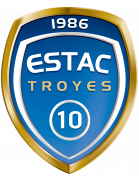
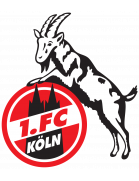
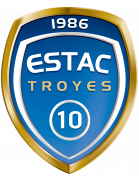
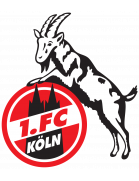
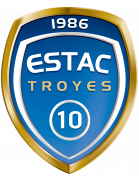
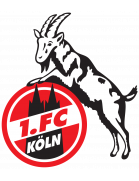

In [2]:
report = PostTrainingAnalysis({
    'Corner totals': MatchResultReporter(type='per_fold', target='corners',
        tolerance=.25, catalog=catalog, show_badges=True, page_size=2),
    'Troyes on either side': MatchResultReporter(type='overall', pooling='first',
        target='corners', tolerance=.25, team=1652,
        catalog=catalog, show_badges=True, page_size=1),
}, title='Synthetic match results').run(training)
report.to_html(output_dir / 'fixtures.html')
report.to_notebook(height=900)

### 3. Inspect the complete retained table

The initial team filter leaves all four observations in this table. Status is
available in data exports for inspection and color provenance. The compact
fixture view uses colors and has no textual Status column.

In [3]:
full_table = report.studies[-1].result.tables['matches::corners']
full_table[['event_id', 'home', 'away', 'result', 'prediction', 'error', 'status']]

,event_id,home,away,result,prediction,error,status
0,101,Troyes,1. FC Köln,8.0,8.00,0.00,within tolerance
1,102,West Bromwich Albion,Coventry City,6.0,6.25,0.25,within tolerance
2,103,Chamois Niortais,Villarreal B U23,5.0,5.60,0.60,outside tolerance
3,104,Troyes,West Bromwich Albion,7.0,NaN,NaN,unavailable


### 4. Compare each side's label

Each team observation keeps its own result/prediction/error group. The first
fixture has one correct side and one error outside tolerance. The second has a
correct side and an unavailable prediction, so its row marker is neutral.
CSV exports retain the separate team-observation rows.


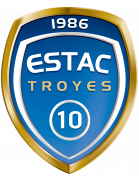
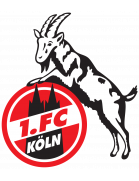
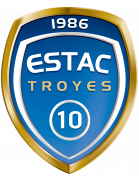
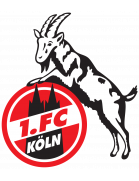

In [4]:
paired_meta = metadata.iloc[[0, 0, 1, 1]].reset_index(drop=True)
paired_meta.index.name = 'row_position'
paired_meta['side'] = ['home', 'away'] * 2
paired_meta['team_id'] = [1652, 2671, 8, 11]
paired_meta['opponent_id'] = [2671, 1652, 11, 8]
paired_y = pd.DataFrame({'corners': [3., 5., 2., 4.]}, index=rows)
paired_prediction = pd.DataFrame({'corners': [3., 5.4, 2., np.nan]}, index=rows)
paired_values = dict(retained, metadata=paired_meta, y_true=paired_y,
                     predictions={'predict': paired_prediction})
paired_training = TrainingResult(
    [FoldResult(fold_id=i, **paired_values) for i in (0, 1)],
    'team_match', (*match_columns, 'team_id'), match_columns, 'team')
paired_report = PostTrainingAnalysis({
    'Home and away corners': MatchResultReporter(type='per_fold', tolerance=.25,
        catalog=catalog, show_badges=True, page_size=2),
}).run(paired_training)
paired_report.to_html(output_dir / 'paired.html')
paired_report.to_notebook(height=900)

## Next steps

The [guide](../docs/analytics/match_results.md) adds custom integer classes,
probability display and optional decisions. The [reference](../docs/analytics/match_results_reference.md)
lists all options and helpers; [equations](../docs/analytics/match_results_equations.md)
define the comparisons. [Coverage](../docs/analytics/match_results_documentation_checklist.md)
and [evidence](../docs/analytics/match_results_check.json) record verification and
its limits. The preceding eleven notebooks remain unchanged.